# GENA expression API walkthrough

This notebook shows the main API objects:

- `Genome`: fetches annotated genomic sequence windows from FASTA/GTF.
- `AnnotatedSequence`: stores DNA plus features and coordinate metadata.
- `Variant`: parses and materializes substitutions/indels.
- `SequencePair`: holds reference/alternative annotated sequences.

In [2]:
from pathlib import Path
from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.genome import Genome
from gena_expression.variants import Variant

In [3]:
DATA_DIR = Path("../data").resolve()
PLASMID_DIR = DATA_DIR / "plasmids"
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
GENOME_GTF = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
)

lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

conditions = {
    cell_type: Condition(name=cell_type, description=lookup[cell_type])
    for cell_type in lookup.keys()
}

genome = Genome(fasta_path=GENOME_FASTA, annotation=GENOME_GTF)

In [5]:
genome.sequence('chr1', 0, 10, strand='+')

AnnotatedSequence(sequence='NNNNNNNNNN', name=None, features=(Feature(name='chr1:0-10', start=0, end=10, type='genome_interval', strand='+', source='genome', metadata={'chrom': 'chr1', 'start': 0, 'end': 10, 'build': None}),), coordinate_map=CoordinateMap(segments=(CoordinateSegment(seq_start=0, seq_end=10, source='genome', chrom='chr1', source_start=0, source_end=10, strand='+', metadata={'build': None}),)), metadata={})

## `Genome` and `AnnotatedSequence`

`Genome.sequence_around(...)` fetches a fixed-size sequence window and can add annotation features from the GTF.

Useful `AnnotatedSequence` methods:

- `plot_annotations(...)`: visualize feature intervals.
- `feature_frame()`: inspect features as a table.
- `feature(name)`: get a named feature.
- `features_overlapping(start, end)`: find features in a region.
- `window(center, size)`: create a smaller centered sequence.
- `add_feature(...)`: return a copy with a new annotation.
- `reverse_complement()`: reverse-complement sequence and remap features.

HBB 10000 GAACGAATGAGTAAATGAGTAAATGAAGGA


,name,start,end,type,strand,source,metadata
0,chr11:5222072-5232072,0,10000,genome_interval,-,genome,"{'chrom': 'chr11', 'start': 5222072, 'end': 52..."
1,AC104389.6,2236,3389,gene,-,HAVANA,"{'chrom': 'chr11', 'genomic_start': 5224308, '..."
2,AC104389.6,2236,3389,transcript,-,HAVANA,"{'chrom': 'chr11', 'genomic_start': 5224308, '..."
3,AC104389.6,2236,3389,exon,-,HAVANA,"{'chrom': 'chr11', 'genomic_start': 5224308, '..."
4,RF00621,2375,2567,gene,-,ENSEMBL,"{'chrom': 'chr11', 'genomic_start': 5224447, '..."


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'HBB genomic context'}, xlabel='Sequence coordinate'>)

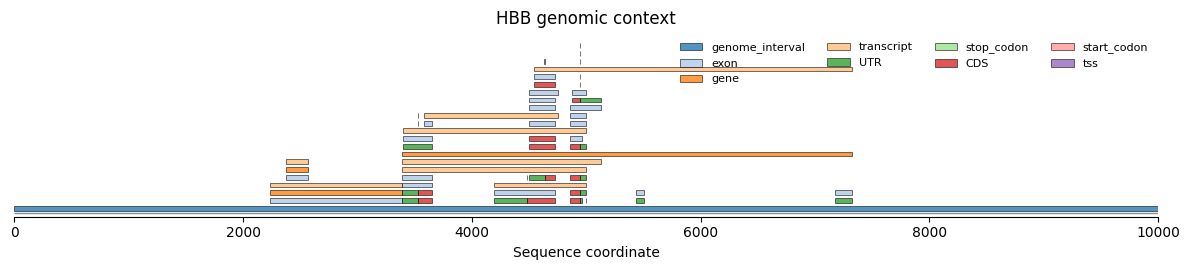

In [4]:
hbb = genome.sequence_around(
    chrom="chr11",
    center=5227072,
    size=10_000,
    strand="-",
    include_features=True,
    center_feature_name="tss",
    name="HBB",
)

print(hbb.name, len(hbb), hbb.sequence[:30])
display(hbb.feature_frame().head())

hbb.plot_annotations(label_features=False, title="HBB genomic context")

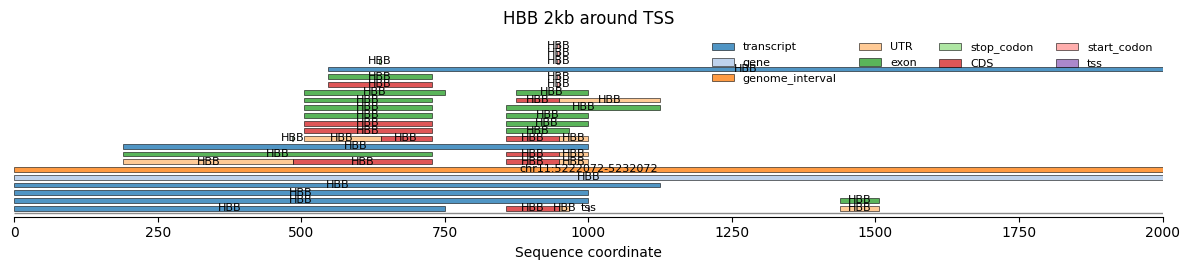

In [ ]:
hbb_small = hbb.window(center="tss", size=2_000, name="HBB 2kb around TSS")
hbb_small.plot_annotations(label_features=True)

## `Variant`

`Variant.from_str(...)` parses strings like `chr2:60494939:C>A`.

Important methods:

- `validate(genome)`: check reference allele against FASTA.
- `plot(...)`: show the allele-level or context-level change.
- `to_sequence_pair(...)`: build a `SequencePair` using a genomic window, primer-defined MPRA fragment, or context object.

## Variant-centered sequence pair

This creates a simple reference/alternative pair by taking a fixed genomic window around the variant.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Reference window annotations'}, xlabel='Sequence coordinate'>)

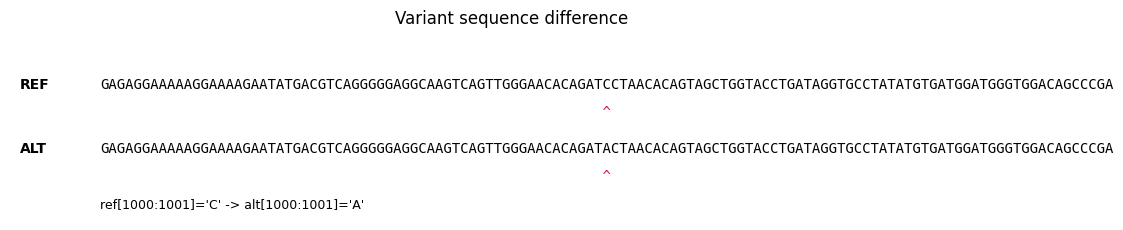

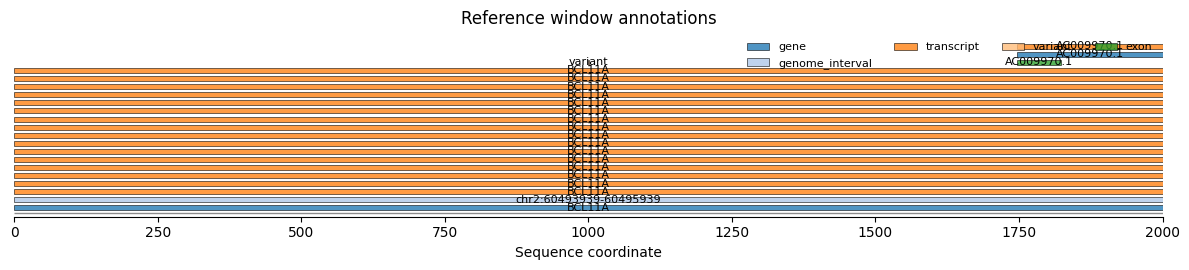

In [ ]:
variant = Variant.from_str(
    "chr2:60494939:C>A",
    genome=genome,
    coordinate_system="0-based",
)
variant.validate(genome=genome) #True

#makes sequence window of size 2000 around variant
window_pair = variant.to_sequence_pair(
    genome=genome,
    window_bp=2_000,
    name="BCL11A_variant_window",
)

window_pair.plot_difference(flank=60)
window_pair.ref.plot_annotations(label_features=True, title="Reference window annotations")

## `SequencePair`

A `SequencePair` stores `ref`, `alt`, and the original `variant`.

Useful methods:

- `plot_difference(...)`: show the exact changed bases.
- `variant_feature()`: locate the variant feature.
- `map(fn)`: apply the same transform to ref and alt.
- `to_dict()`: serialize pair metadata.

In [14]:
print(len(window_pair.ref), len(window_pair.alt))
print(window_pair.variant_feature())

display(window_pair.ref.feature_frame().head())

2000 2000
Feature(name='variant', start=1000, end=1001, type='variant', strand=None, source='variant', metadata={'chrom': 'chr2', 'pos': 60494939, 'ref': 'C', 'alt': 'A', 'id': 'chr2:60494939:C>A', 'strand': '+', 'metadata': {}})


,name,start,end,type,strand,source,metadata
0,chr2:60493939-60495939,0,2000,genome_interval,+,genome,"{'chrom': 'chr2', 'start': 60493939, 'end': 60..."
1,BCL11A,0,2000,transcript,-,HAVANA,"{'chrom': 'chr2', 'genomic_start': 60450519, '..."
2,BCL11A,0,2000,gene,-,HAVANA,"{'chrom': 'chr2', 'genomic_start': 60450519, '..."
3,BCL11A,0,2000,transcript,-,HAVANA,"{'chrom': 'chr2', 'genomic_start': 60451145, '..."
4,BCL11A,0,2000,transcript,-,HAVANA,"{'chrom': 'chr2', 'genomic_start': 60451166, '..."


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Trimmed ALT sequence'}, xlabel='Sequence coordinate'>)

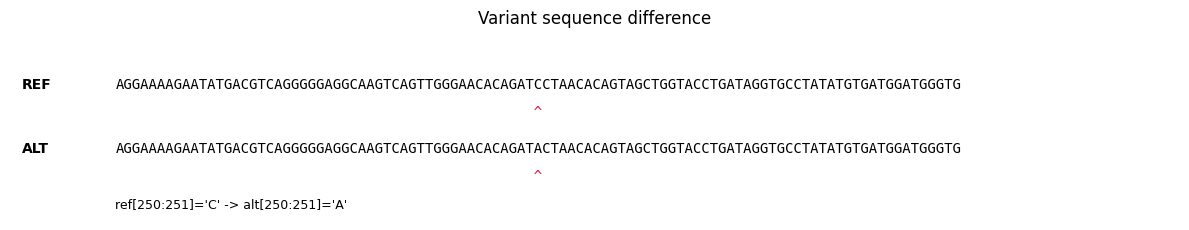

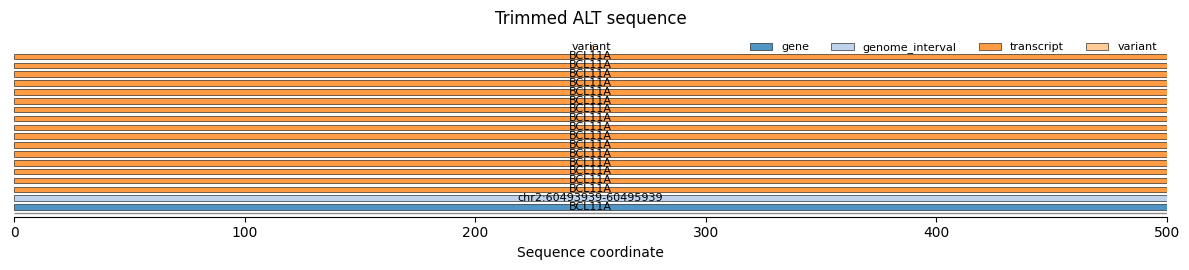

In [18]:
trimmed_pair = window_pair.map(
    lambda seq: seq.window(center="variant", size=500, name=f"{seq.name}_500bp")
)

trimmed_pair.plot_difference(flank=50)
trimmed_pair.ref.plot_annotations(label_features=True, title="Trimmed ALT sequence")